In [80]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

prices = pd.read_csv("../prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns.tolist()

N_five = 5
N_ten = 10
N_twenty = 20

market_returns = returns.sum(axis=1)
market_rolling_returns_5 = market_returns.rolling(N_five).mean()
market_rolling_returns_10 = market_returns.rolling(N_ten).mean()
market_rolling_returns_20 = market_returns.rolling(N_twenty).mean()


market_rolling_vol_5 = market_returns.rolling(N_five).std()
market_rolling_vol_10 = market_returns.rolling(N_ten).std()
market_rolling_vol_20 = market_returns.rolling(N_twenty).std()

market_data = {"market_rolling_returns_5": market_rolling_returns_5[N_twenty - 1:],
                "market_rolling_returns_10": market_rolling_returns_10[N_twenty - 1:],
                "market_rolling_returns_20": market_rolling_returns_20[N_twenty - 1:],
                "market_rolling_vol_5": market_rolling_vol_5[N_twenty - 1:],
                "market_rolling_vol_10": market_rolling_vol_10[N_twenty - 1:],
                "market_rolling_vol_20": market_rolling_vol_20[N_twenty - 1:]}





Model Directional Accuracy for ALGO: 41.24%
Model Directional Accuracy for AENO: 60.82%


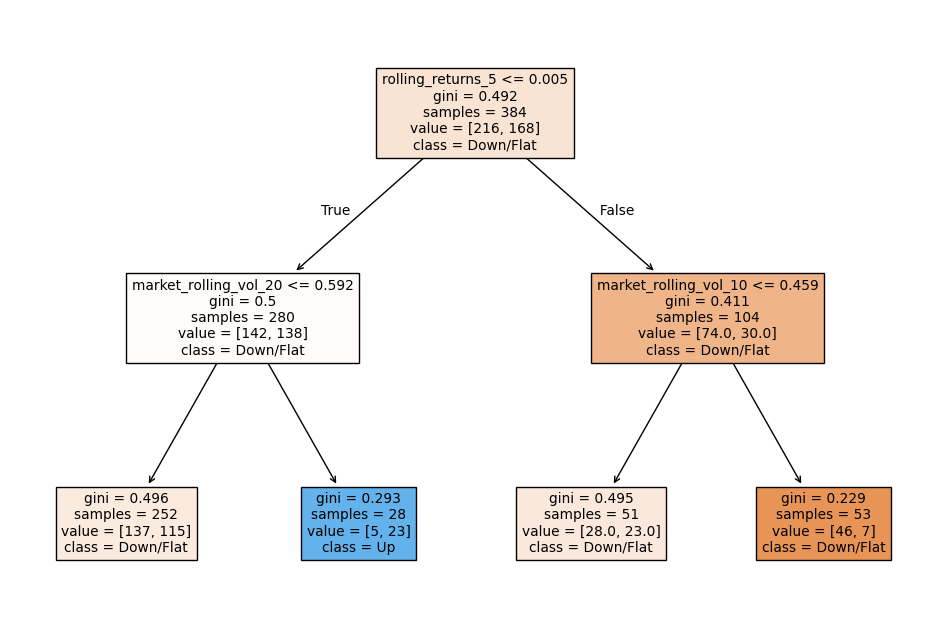

Model Directional Accuracy for LSST: 61.86%


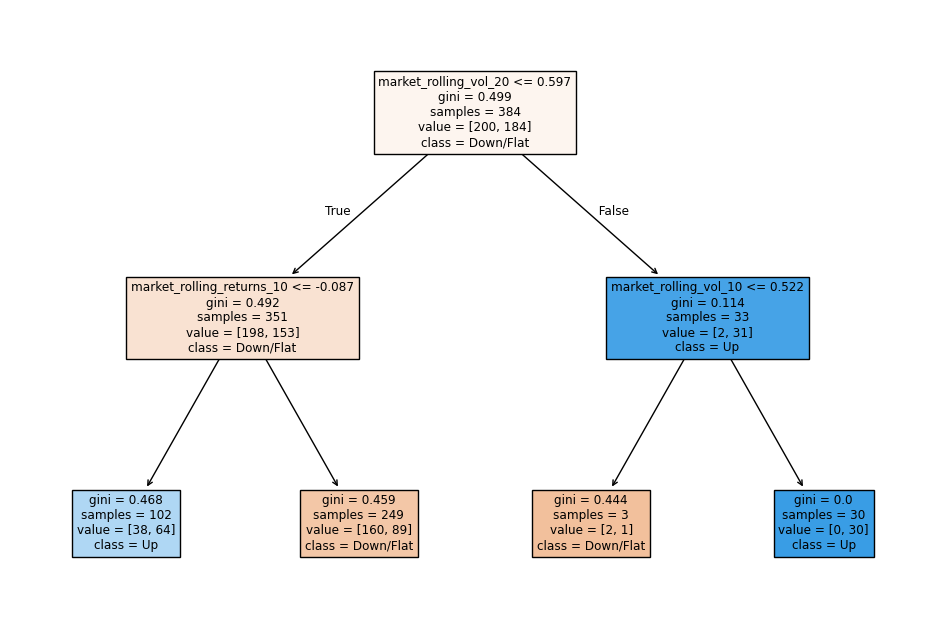

Model Directional Accuracy for SRNA: 67.01%


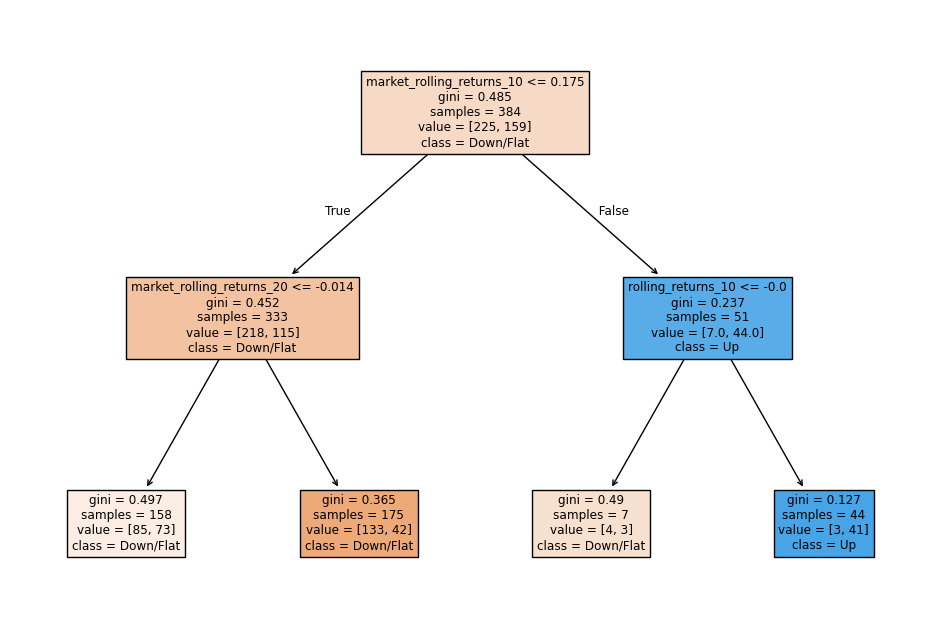

Model Directional Accuracy for ELLT: 36.08%
Model Directional Accuracy for AMRP: 69.07%


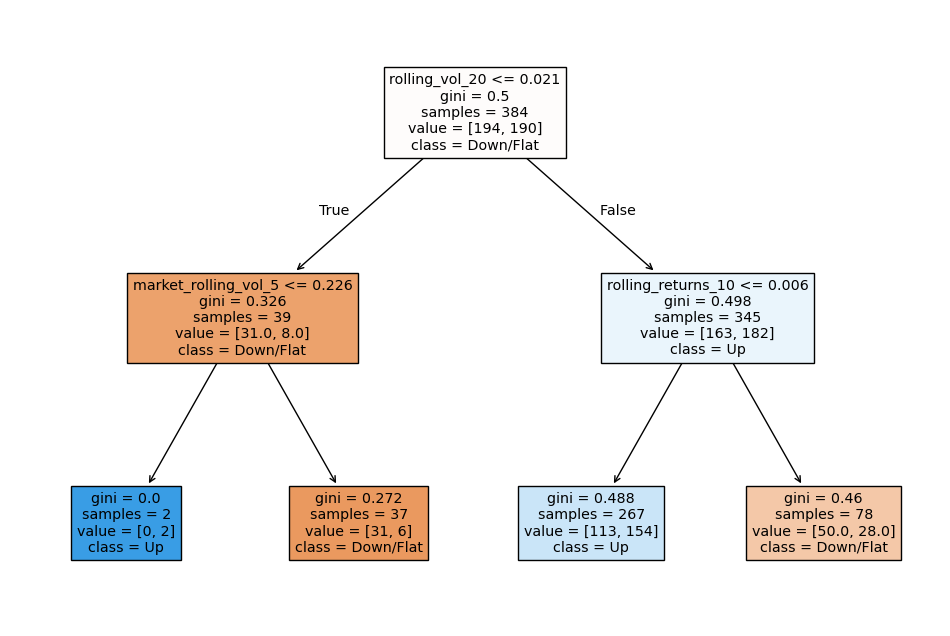

Model Directional Accuracy for OTCS: 58.76%
Model Directional Accuracy for HETT: 36.08%
Model Directional Accuracy for HUXZ: 41.24%
Model Directional Accuracy for DUCT: 42.27%
Model Directional Accuracy for SMAH: 42.27%
Model Directional Accuracy for NPCK: 57.73%
Model Directional Accuracy for MSDP: 53.61%
Model Directional Accuracy for EORC: 70.10%


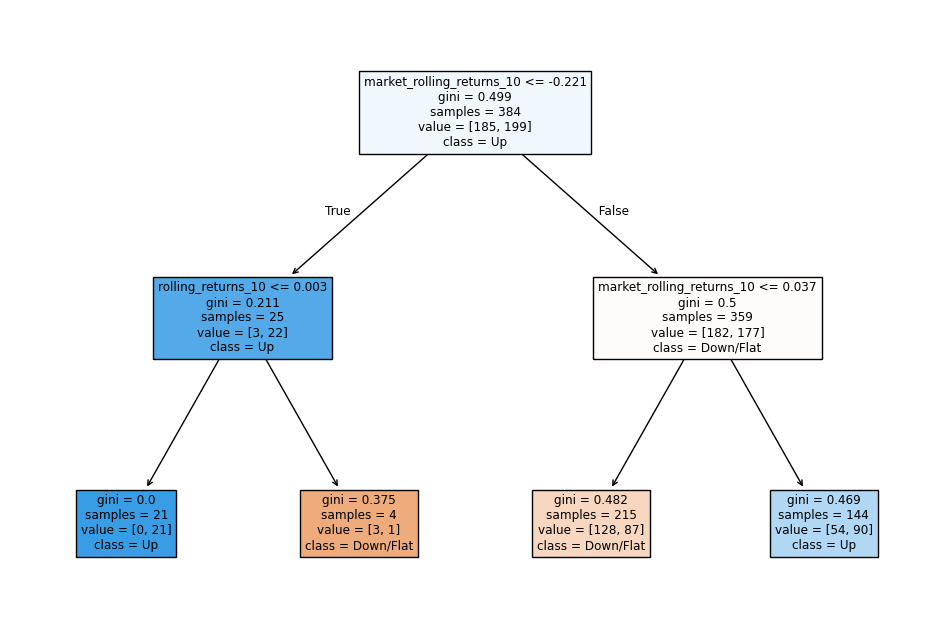

Model Directional Accuracy for CUBO: 43.30%
Model Directional Accuracy for HRET: 48.45%
Model Directional Accuracy for ANSO: 48.45%
Model Directional Accuracy for DIHO: 49.48%
Model Directional Accuracy for RTTH: 58.76%
Model Directional Accuracy for SPLZ: 57.73%
Model Directional Accuracy for NWIG: 40.21%
Model Directional Accuracy for MMBT: 39.18%
Model Directional Accuracy for MDGI: 35.05%
Model Directional Accuracy for AGVF: 50.52%
Model Directional Accuracy for RRES: 41.24%
Model Directional Accuracy for CTGI: 51.55%
Model Directional Accuracy for ALUT: 58.76%
Model Directional Accuracy for ACAC: 61.86%


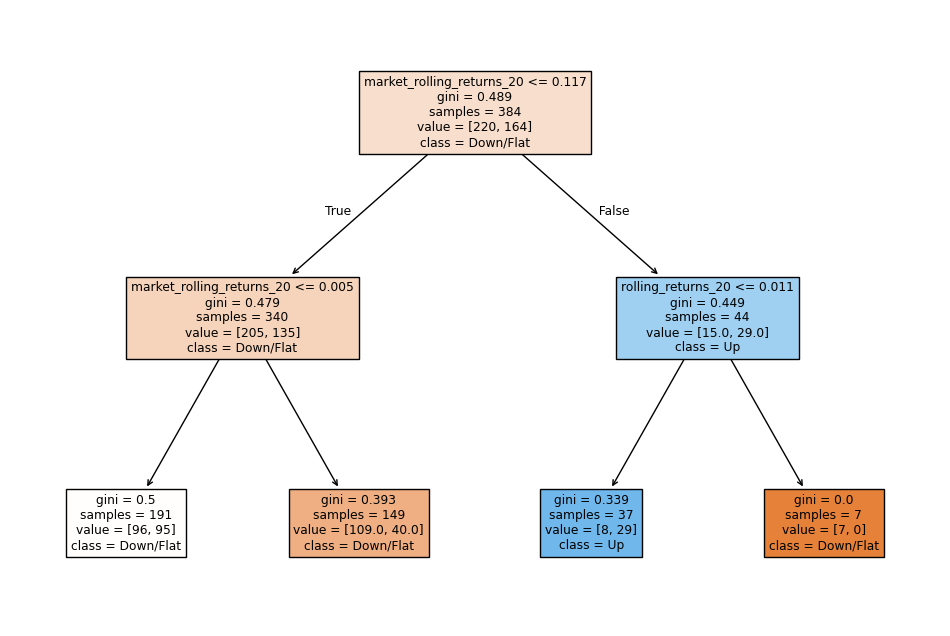

Model Directional Accuracy for SRTX: 75.26%


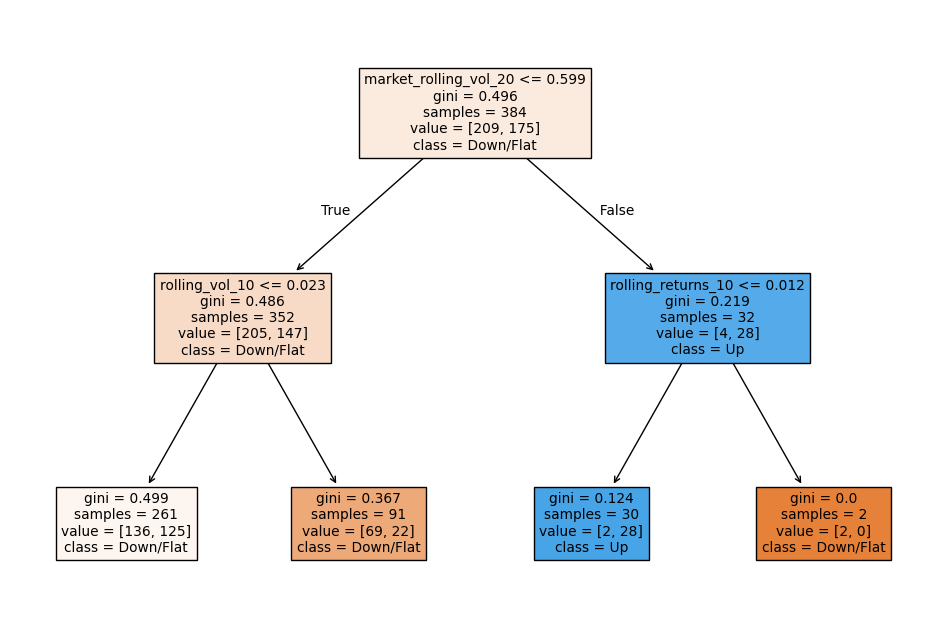

Model Directional Accuracy for GARI: 50.52%
Model Directional Accuracy for RCRI: 41.24%
Model Directional Accuracy for ACIX: 51.55%
Model Directional Accuracy for CCNS: 43.30%
Model Directional Accuracy for MTNS: 65.98%


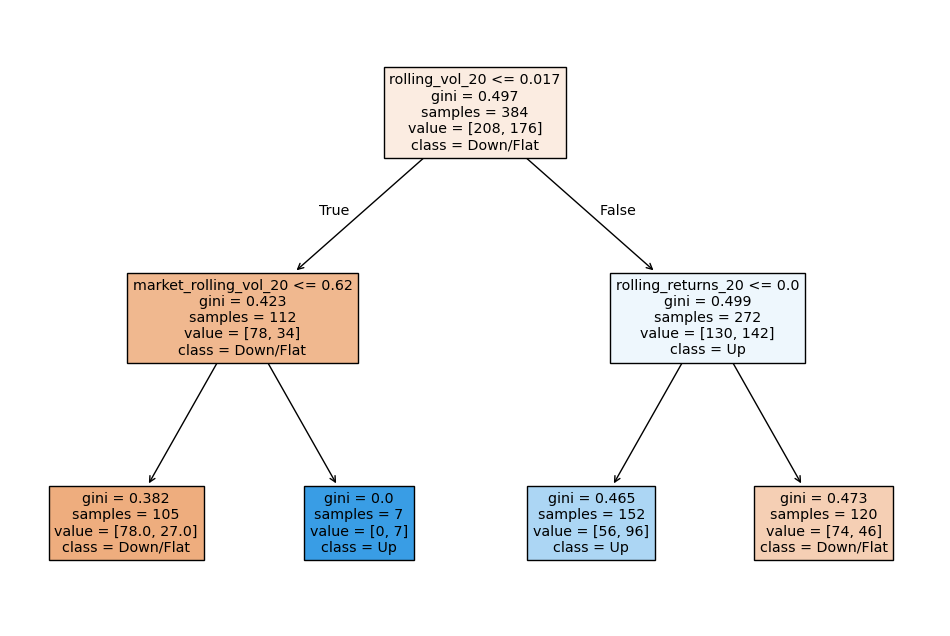

Model Directional Accuracy for IHOZ: 62.89%


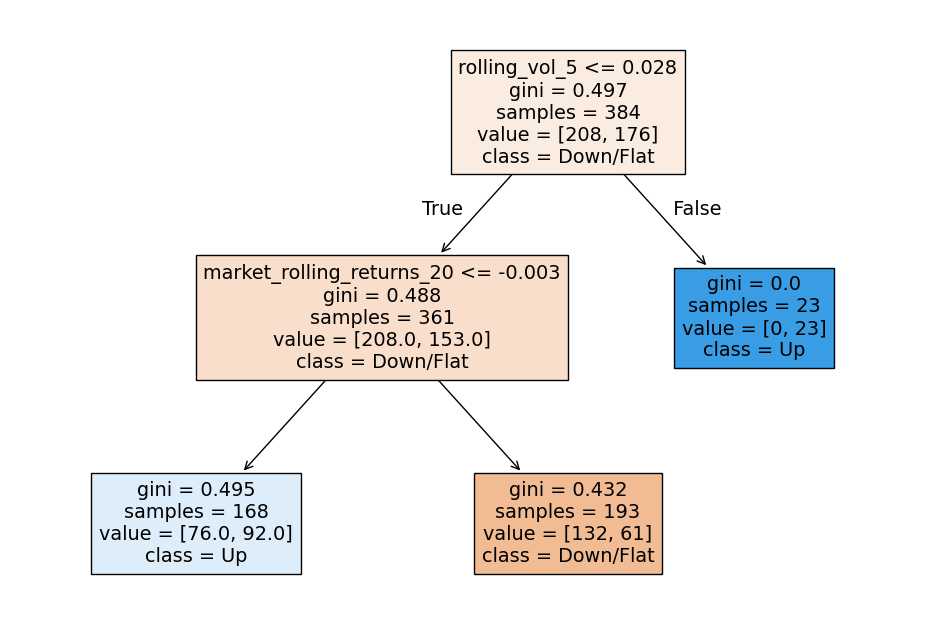

Model Directional Accuracy for NAYO: 52.58%
Model Directional Accuracy for FWWG: 46.39%
Model Directional Accuracy for EELT: 46.39%
Model Directional Accuracy for HRND: 65.98%


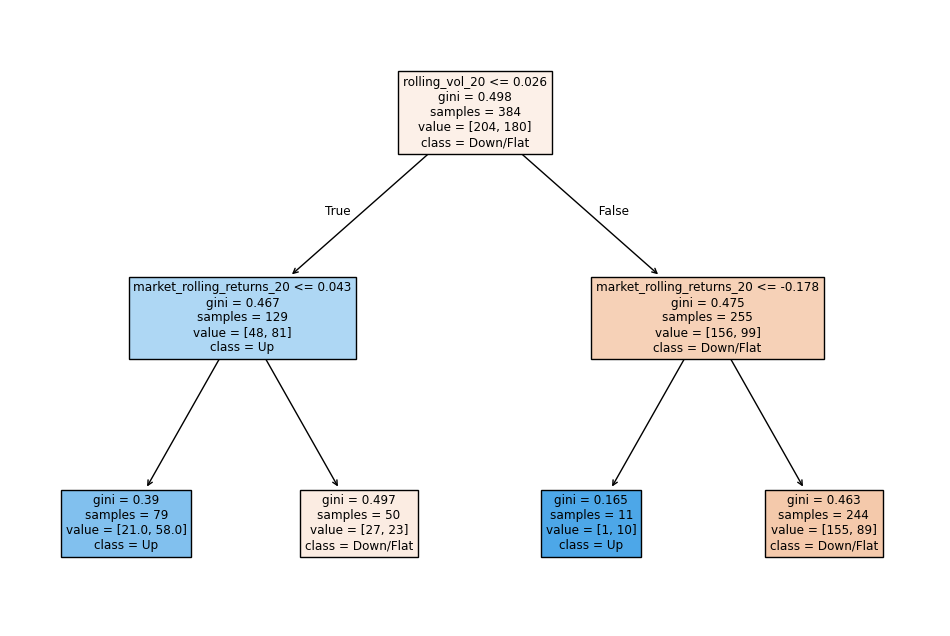

Model Directional Accuracy for AETS: 41.24%
Model Directional Accuracy for ULXY: 51.55%
Model Directional Accuracy for BLBT: 48.45%
Model Directional Accuracy for BENI: 53.61%
Model Directional Accuracy for ITPA: 38.14%
Model Directional Accuracy for HTRK: 55.67%
Model Directional Accuracy for NGTE: 37.11%
Model Directional Accuracy for ILVX: 29.90%
Model Directional Accuracy for FCSG: 57.73%
Model Directional Accuracy for FARS: 64.95%


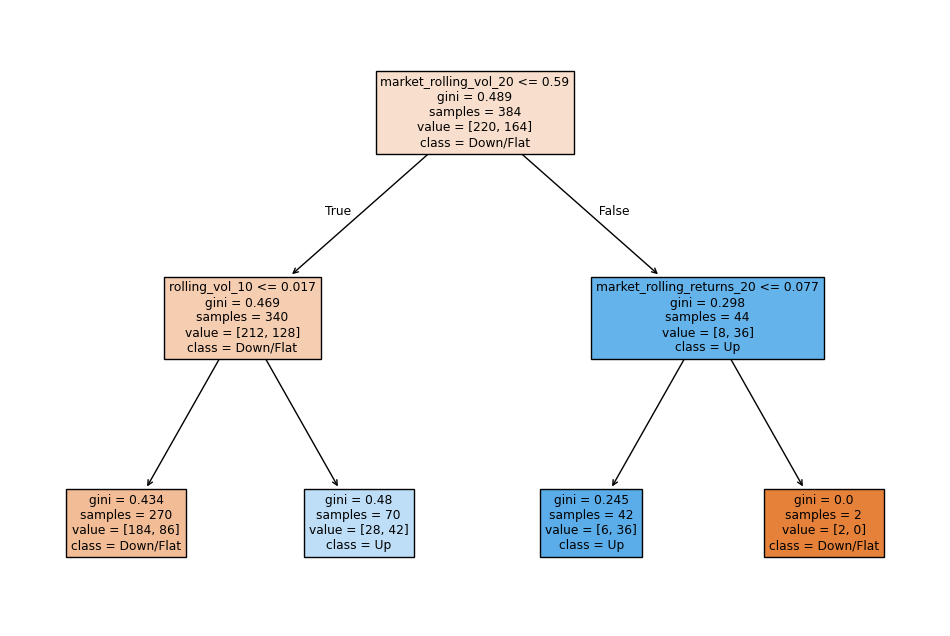

Model Directional Accuracy for MHRM: 42.27%
Model Directional Accuracy for EAFC: 59.79%


In [81]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
# assets = ["ALGO"]

for asset in assets:
    N_future_returns_days = 5
    asset_returns = returns[asset]
    target = asset_returns.shift(-1).rolling(N_future_returns_days).mean().shift(-(N_future_returns_days-1))
    target = target[19:]
    N_five = 4
    N_ten = 10
    N_twenty = 20
    rolling_returns_5 = asset_returns.rolling(N_five).mean()
    rolling_returns_10 = asset_returns.rolling(N_ten).mean()
    rolling_returns_20 = asset_returns.rolling(N_twenty).mean()
    rolling_vol_5 = asset_returns.rolling(N_five).std()
    rolling_vol_10 = asset_returns.rolling(N_ten).std()
    rolling_vol_20 = asset_returns.rolling(N_twenty).std()
    data = {"rolling_returns_5": rolling_returns_5[N_twenty - 1:],
        "rolling_returns_10": rolling_returns_10[N_twenty - 1:],
        "rolling_returns_20": rolling_returns_20[N_twenty - 1:],
        "rolling_vol_5": rolling_vol_5[N_twenty - 1:],
        "rolling_vol_10": rolling_vol_10[N_twenty - 1:],
        "rolling_vol_20": rolling_vol_20[N_twenty - 1:]}
    data["target"] = target
    
    data = data | market_data
    
    data = pd.DataFrame(data)
    target = np.where(data['target'] > 0, 1, 0)
    data = data.drop(columns = ["target"])
    
    X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, shuffle=False)
    model = DecisionTreeClassifier(max_depth=2, random_state=42)
    model.fit(X_train, y_train)
    
    # 5. Predict and Evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Directional Accuracy for {asset}: {accuracy:.2%}")

    if accuracy > 0.6:
        plt.figure(figsize=(12, 8))
        plot_tree(model, feature_names=data.columns, class_names=['Down/Flat', 'Up'], filled=True)
        plt.show()


In [76]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
assets = ["ALGO"]

for asset in assets:
    N_future_returns_days = 5
    asset_returns = returns[asset]
    target = asset_returns.shift(-1).rolling(N_future_returns_days).mean().shift(-(N_future_returns_days-1))
    target = target[19:]
    N_five = 5
    N_ten = 10
    N_twenty = 20
    rolling_returns_5 = asset_returns.rolling(N_five).mean()
    rolling_returns_10 = asset_returns.rolling(N_ten).mean()
    rolling_returns_20 = asset_returns.rolling(N_twenty).mean()
    rolling_vol_5 = asset_returns.rolling(N_five).std()
    rolling_vol_10 = asset_returns.rolling(N_ten).std()
    rolling_vol_20 = asset_returns.rolling(N_twenty).std()
    data = {"rolling_returns_5": rolling_returns_5[N_twenty - 1:],
        "rolling_returns_10": rolling_returns_10[N_twenty - 1:],
        "rolling_returns_20": rolling_returns_20[N_twenty - 1:],
        "rolling_vol_5": rolling_vol_5[N_twenty - 1:],
        "rolling_vol_10": rolling_vol_10[N_twenty - 1:],
        "rolling_vol_20": rolling_vol_20[N_twenty - 1:]}
    data["future_returns"] = target
    
    data = data | market_data
    
    data = pd.DataFrame(data)
    columns = list(data.columns)
    for col in columns:
        data["bucket_" + (col)] = pd.qcut(data[col], q=10)
        bucket_stats = data.groupby("bucket_" + col)["future_returns"].agg(mean_return="mean", std_return="std", count="count")
        print(bucket_stats)



19     0.023067
20    -0.045312
21    -0.174186
22    -0.114067
23    -0.003593
         ...   
495   -0.311863
496   -0.076512
497   -0.006796
498    0.204356
499    0.350155
Name: market_rolling_returns_5, Length: 481, dtype: float64
HELLO:  481 rolling_returns_5
                                   mean_return  std_return  count
bucket_rolling_returns_5                                         
(-0.014499999999999999, -0.00582]     0.001894    0.004043     48
(-0.00582, -0.00392]                  0.000604    0.003437     48
(-0.00392, -0.00242]                 -0.000850    0.004091     47
(-0.00242, -0.00133]                 -0.000083    0.004132     47
(-0.00133, -0.000316]                -0.000985    0.003896     48
(-0.000316, 0.000704]                -0.000404    0.004687     48
(0.000704, 0.00187]                  -0.001350    0.004445     47
(0.00187, 0.00318]                   -0.001260    0.004796     48
(0.00318, 0.00486]                   -0.000307    0.005054     47
(0.00486

/var/folders/4r/s0txvjgx4gzb3kzxks91z1680000gn/T/ipykernel_29052/2570647535.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = data.groupby("bucket_" + col)["future_returns"].agg(mean_return="mean", std_return="std", count="count")
/var/folders/4r/s0txvjgx4gzb3kzxks91z1680000gn/T/ipykernel_29052/2570647535.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = data.groupby("bucket_" + col)["future_returns"].agg(mean_return="mean", std_return="std", count="count")
/var/folders/4r/s0txvjgx4gzb3kzxks91z1680000gn/T/ipykernel_29052/2570647535.py:38: FutureWarning: The default of obser